In [24]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder,StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

In [25]:
data=pd.read_csv(r"C:\Users\abody\Desktop\Final Project Sprints\Heart_Disease_Project\data\processed.cleveland.data")
df=pd.DataFrame(data) 

In [26]:
df.columns=["age","sex","Chestpain","RestingBP","Cholesterol","FastingBS","RestingECG","Maxheartrate","Exercise-Induced_Angina","ST_Depression","Slope","No_Vessels","Thalassemia","Target"] 

In [27]:
df

,age,sex,Chestpain,RestingBP,Cholesterol,FastingBS,RestingECG,Maxheartrate,Exercise-Induced_Angina,ST_Depression,Slope,No_Vessels,Thalassemia,Target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
298,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
299,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
300,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      302 non-null    float64
 1   sex                      302 non-null    float64
 2   Chestpain                302 non-null    float64
 3   RestingBP                302 non-null    float64
 4   Cholesterol              302 non-null    float64
 5   FastingBS                302 non-null    float64
 6   RestingECG               302 non-null    float64
 7   Maxheartrate             302 non-null    float64
 8   Exercise-Induced_Angina  302 non-null    float64
 9   ST_Depression            302 non-null    float64
 10  Slope                    302 non-null    float64
 11  No_Vessels               302 non-null    object 
 12  Thalassemia              302 non-null    object 
 13  Target                   302 non-null    int64  
dtypes: float64(11), int64(1), 

In [29]:
null_rows=df[df.isin(["?"]).any(axis=1)].index
print(null_rows)
df.drop(null_rows,axis=0,inplace=True)

Index([86, 165, 191, 265, 286, 301], dtype='int64')


In [30]:
print(df["No_Vessels"].unique())
print(df["Thalassemia"].unique())

['3.0' '2.0' '0.0' '1.0']
['3.0' '7.0' '6.0']


In [31]:
ohe = OneHotEncoder(sparse_output=False) 
encoded_vess = ohe.fit_transform(df[["No_Vessels"]]) 
vess_cols = [f"{cat:.1}_Damaged_Vessel" for cat in ohe.categories_[0]] 
df[vess_cols] = encoded_vess 

thalassemia={3.0:"No_Thalassemia",6.0:"Fixed_Thalassemia",7.0:"Reversible"} 
encoded_thalass=ohe.fit_transform(df[["Thalassemia"]]) 
thalass_col=[thalassemia[float(cat)] for cat in ohe.categories_[0]] 
df[thalass_col]=encoded_thalass

In [32]:
df.drop(columns=['No_Vessels','Thalassemia'],inplace=True)

In [33]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 296 entries, 0 to 300
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      296 non-null    float64
 1   sex                      296 non-null    float64
 2   Chestpain                296 non-null    float64
 3   RestingBP                296 non-null    float64
 4   Cholesterol              296 non-null    float64
 5   FastingBS                296 non-null    float64
 6   RestingECG               296 non-null    float64
 7   Maxheartrate             296 non-null    float64
 8   Exercise-Induced_Angina  296 non-null    float64
 9   ST_Depression            296 non-null    float64
 10  Slope                    296 non-null    float64
 11  Target                   296 non-null    int64  
 12  0_Damaged_Vessel         296 non-null    float64
 13  1_Damaged_Vessel         296 non-null    float64
 14  2_Damaged_Vessel         296 no

In [34]:
df["age_raw"]=df["age"]

In [35]:
scaler = StandardScaler() 
numerical=["age","RestingBP","Cholesterol","Maxheartrate"] 
df[numerical]=scaler.fit_transform(df[numerical])

In [36]:
age_thal_counts = df.groupby("age_raw")[["Fixed_Thalassemia", "Reversible"]].sum().reset_index()

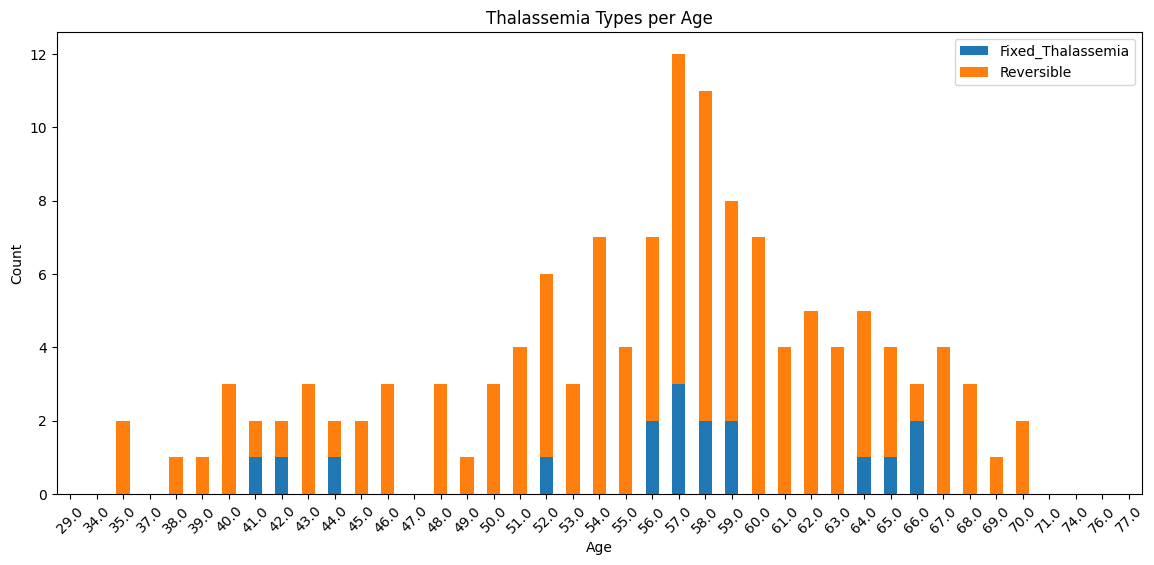

In [37]:
age_thal_counts.plot( x="age_raw", y=["Fixed_Thalassemia", "Reversible"], kind="bar", stacked=True, figsize=(14,6) ) 
plt.ylabel("Count") 
plt.title("Thalassemia Types per Age") 
plt.xticks(rotation=45) 
plt.xlabel("Age") 
plt.show()

(array([0, 1]), [Text(0, 0, 'Female'), Text(1, 0, 'Male')])

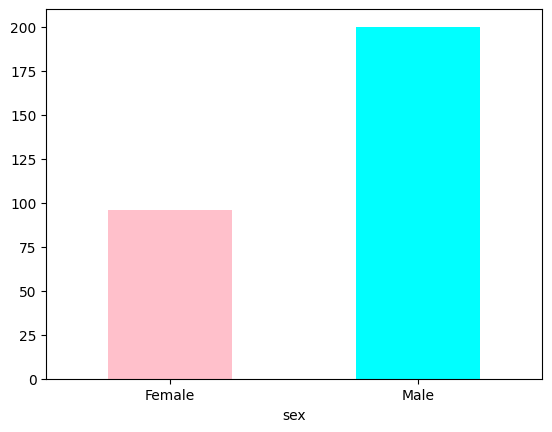

In [38]:
genders=df.groupby("sex")["sex"].count() 
genders.index=genders.index.map({0.0:"Female",1.0:"Male"}) 
genders.plot( x="sex", y="sex", kind="bar", color=["pink","cyan"], )
plt.xticks(rotation=0)

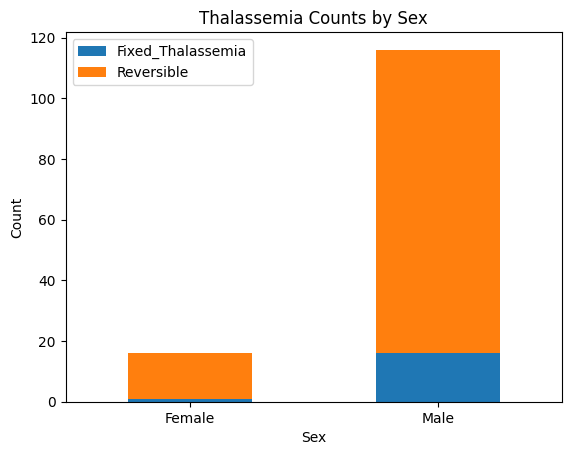

In [39]:
sex_thal_count=df.groupby("sex")[["Fixed_Thalassemia", "Reversible"]].sum().reset_index() 
sex_thal_count.index=sex_thal_count.index.map({0.0:"Female",1.0:"Male"}) 
sex_thal_count.plot( y=["Fixed_Thalassemia", "Reversible"], kind="bar", stacked=True ) 
plt.title("Thalassemia Counts by Sex") 
plt.ylabel("Count") 
plt.xlabel("Sex") 
plt.xticks(rotation=0) 
plt.show()

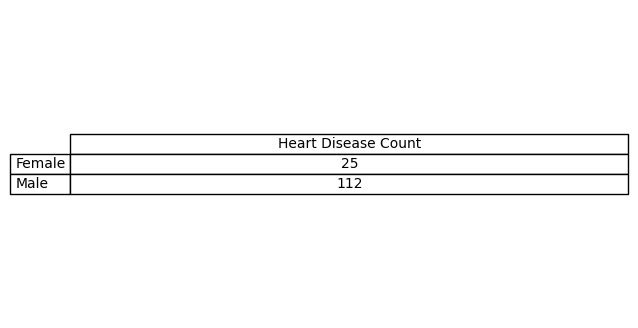

In [44]:
# Count only cases where Target > 0 (has heart disease)
gen_target_count = df[df['Target'] > 0].groupby('sex').size().reset_index(name='Heart_Disease_Count')
gen_target_count.index = gen_target_count.index.map({0.0: "Female", 1.0: "Male"})

fig, ax = plt.subplots(figsize=(6, 4)) 
ax.axis("off") 
tbl = ax.table( 
    cellText=gen_target_count[['Heart_Disease_Count']].values, 
    colLabels=["Heart Disease Count"], 
    rowLabels=gen_target_count.index, 
    cellLoc="center", 
    loc="center" 
) 
tbl.auto_set_font_size(False) 
tbl.set_fontsize(10) 
tbl.scale(1.2, 1.2)
plt.show()

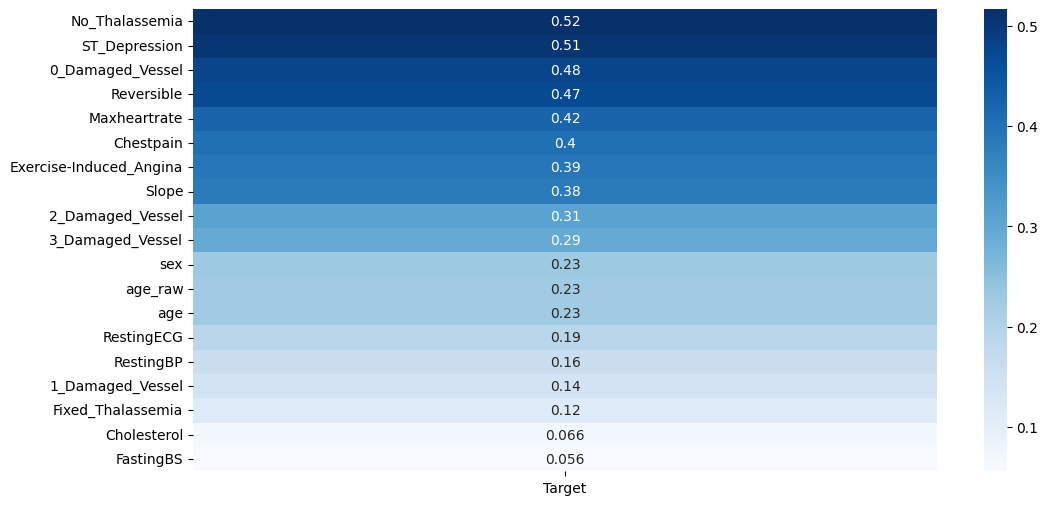

In [45]:
corr=np.abs(df.corr()["Target"].drop("Target")).sort_values(ascending=False) 
fig=plt.figure(figsize=(12,6))
sns.heatmap(corr.to_frame(),annot=True,cmap="Blues")
plt.show()

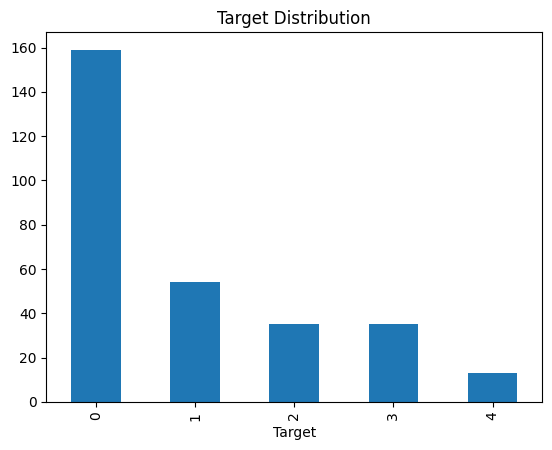

In [46]:
df["Target"].value_counts().plot(kind="bar") 
plt.title("Target Distribution") 
plt.show()

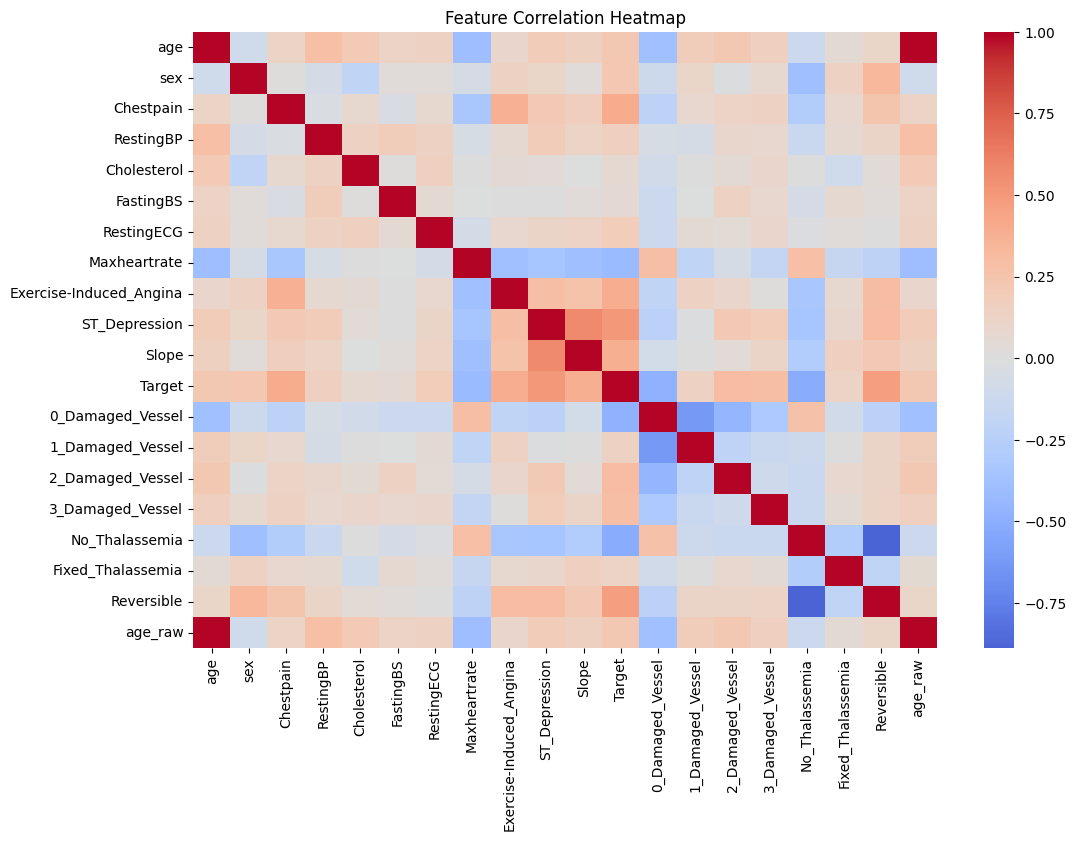

In [47]:
plt.figure(figsize=(12,8)) 
sns.heatmap(df.corr(), cmap="coolwarm", center=0) 
plt.title("Feature Correlation Heatmap") 
plt.show()

In [48]:
df.to_csv(r"C:\Users\abody\Desktop\Final Project Sprints\Heart_Disease_Project\data\Cleaned")